# Асимптотический анализ световых возмущений орбит ИСЗ методом преобразований Ли-Депри


### Введение

Конспект посвящен полуаналитическому моделированию динамического воздействия давления солнечного излучения на эволюцию орбит искусственных спутников Земли (ИСЗ) [Брумберг, 1980]. В отличие от классических задач движения в гравитационном поле планеты, где возмущающая функция зависит исключительно от пространственных координат аппарата, гамильтониан светового давления является явно неавтономным. Зависимость от времени вводится в систему через видимое годовое перемещение Солнца по эклиптике [Musen, 1960].

Для аналитического решения неавтономной задачи в работе реализуется алгоритм, сочетающий методы гамильтоновой механики и аппарата компьютерной алгебры:

1. **Автономизация уравнений движения:** Классический рекуррентный алгоритм Депри, предназначенный для стационарных систем, адаптируется под нестационарный фазовый поток по методу Дж. Хори [Hori, 1966; Deprit, 1969]. Посредством введения расширенного восьмимерного фазового пространства Делоне и сопряженной канонической пары «время-энергия» неавтономная система преобразуется в стационарную. Это позволяет вычислять производящие функции Ли через аналитические частные производные в расширенной симплектической структуре [Whittaker, 1937].
2. **Учет многочастотного спектра возмущений:** Построенная асимптотическая теория первого порядка осуществляет суперпозицию сил различной физической природы. Вековая гравитационная прецессия плоскости орбиты и линии апсид от полярного сжатия Земли ($J_2$) интегрируется в общую схему в качестве основных частот медленных переменных [Brouwer, 1959]. Такой подход позволяет исследовать апсидно-узловые вековые резонансы высоких орбит (включая геостационарную орбиту), где частота ухода узла становится соизмеримой с частотой движения Солнца [El-Enna, 2004; Мельников, 2024].
3. **Численно-аналитический контроль точности:** Аналитическое решение первого приближения сопоставляется с численным решением уравнений движения в декартовых координатах, полученным методом Рунге-Кутты 8-го порядка (алгоритм DOP853) [Meyer, Hall, 1992]. Использование вычисленного символьного генератора Ли в качестве динамического фильтра позволяет продемонстрировать подавление короткопериодических возмущений в оскулирующих элементах орбиты [Radzievskii, 1960; Мельников, 2024].


## Раздел 1. Динамические эффекты и структура неавтономных гамильтоновых уравнений

### 1.1. Физическая природа и частотные масштабы возмущения

Ускорение, сообщаемое космическому аппарату давлением солнечного излучения в рамках модели плоской пластины со смешанным характером отражения, определяется выражением [Брумберг, 1980]:
$$\vec{a} = -\mathcal{F}_{\mathrm{solar}}\vec{e}_{\odot}$$

где:
*   $\mathcal{F}_{\mathrm{solar}} = (1 + R_{\mathrm{ref}})P_{\odot}\left(\frac{A}{m}\right)$ - масштабирующий силовой коэффициент светового давления,
*   $P_{\odot} \approx 4.56 \cdot 10^{-6}$ Н/м$^2$ — среднее давление солнечного излучения на расстоянии 1 а.е.,
*   $A/m$ - баллистический коэффициент парусности космического аппарата (отношение площади миделева сечения к массе),
*   $R_{\mathrm{ref}}$ - коэффициент отражения поверхности аппарата,
*   $\vec{e}_{\odot} = \vec{r}_{\odot} / r_{\odot}$ - единичный геоцентрический вектор направления на Солнце ($\vec{r}_{\odot}$ - геоцентрический радиус-вектор Солнца).

При переходе к каноническим переменным «действие-угол» Делоне возмущающая гамильтонова функция светового давления становится явно зависящей от времени из-за орбитального движения Земли вокруг Солнца. Частотный спектр полученной системы характеризуется тремя несоизмеримыми частотами:
1. **Быстрая частота ($n_{\mathrm{orb}}$):** обусловленная орбитальным движением спутника (средняя аномалия $l$).
2. **Медленные частоты ($\dot{g}, \dot{h}$):** определяемые вековой гравитационной прецессией линии апсид и линии узлов орбиты под действием зональной гармоники геопотенциала $J_2$.
3. **Эклиптическая частота ($n_{\odot}$):** определяемая видимым годовым движением Солнца по эклиптике (средняя долгота Солнца $\lambda_{\odot} = n_{\odot}t + \lambda_{\odot,0}$, где $n_{\odot} \approx 0.9856^\circ$/сут).

> **Примечание (Учет радиационной асимметрии):**
> В задачах долгосрочного прогнозирования орбит космических аппаратов с высоким значением коэффициента парусности ($A/m$) радиальная модель сил (1) подлежит модификации с целью учета геометрической анизотропии отражения. Возникновение тангенциальной (поперечной) составляющей светового ускорения, обусловленной смешанным зеркально-диффузным рассеянием и неравномерным тепловым переизлучением элементов конструкции (эффект Ярковского-Радзиевского), нарушает консервативность фазового потока на освещенных участках траектории, вызывая вековые изменения наклонения и долготы восходящего узла орбиты [Радзиевский, 1960].

---

### 1.2. Динамические эффекты

Взаимодействие собственных частот ИСЗ и частоты движения источника возмущения обуславливает возникновение трех динамических явлений в эволюции околоземных орбит [Brouwer, 1959; Брумберг, 1980]:
*   **Долгопериодическая деформация эксцентриситета (эффект Радзиевского):** Давление солнечного излучения нарушает пространственную симметрию сил относительно перицентра и апоцентра орбиты, вследствие чего результирующая работа возмущающей силы за один виток отлична от нуля [Radzievskii, 1960]. Эксцентриситет околокруговых орбит испытывает широкоамплитудные долгопериодические колебания с периодом, ассоциированным со средним движением Солнца ($2\pi / n_{\odot}$), либо с периодом обращения линии апсид. Для космических объектов с высоким значением коэффициента парусности $A/m$ (объекты космического мусора, фрагменты экранно-вакуумной теплоизоляции) амплитуда колебаний может приводить к увеличению эксцентриситета до значений $0.1 - 0.2$, что вызывает падение высоты перицентра и последующее разрушение аппарата в плотных слоях атмосферы.

*   **Изменение большой полуоси орбиты при учете тени Земли:** При движении ИСЗ по полностью освещенной траектории интегральная работа сил светового давления за полный виток равна нулю, что гарантирует инвариантность большой полуоси (канонического импульса действия $L$). При пересечении спутником геометрической тени Земли радиационное ускорение обращается в ноль на теневой дуге витка [Musen, 1960]. Нарушение симметрии подынтегральной функции порождает непрерывный вековой дрейф большой полуоси, знак и скорость которого определяются взаимной геометрией вектора орбитального момента и направления на Солнце.

*   **Апсидно-узловые вековые резонансы в окрестности геостационарной орбиты:** В окрестности геостационарной орбиты частота гравитационной прецессии узла $\dot{h}$ становится соизмеримой со средним движением Солнца $n_{\odot}$. В знаменателях асимптотических рядов теории возмущений возникают малые резонансные разности $(\dot{h} - n_{\odot}) \to 0$ [El-Enna, 2004]. Данный вековой резонанс индуцирует долгопериодические колебания плоскости орбиты неактивных геостационарных спутников с трансформацией наклонения от $0^\circ$ до $15^\circ$ на интервале порядка 53 лет, уводя космический аппарат из экваториальной области [Brouwer, 1959; Мельников, 2024].

---

### 1.3. Концепция неавтономного исчисления Ли-Депри

Задача построения аналитической теории движения под действием сил давления солнечного излучения заключается в исключении явной зависимости гамильтониана от времени при сохранении симплектических свойств канонических преобразований фазового пространства. Эта задача решается в соответствии со следующей схемой:

$$\mathcal{H}(L, G, H_{\mathrm{del}}, l, g, h, t)$$
$$\Downarrow$$
$$\text{[Переход к расширенному фазовому пространству]}$$
$$\Downarrow$$
$$\text{Автономный гамильтониан расширенной системы: } \mathcal{K} = \mathcal{H}(L, G, H_{\mathrm{del}}, l, g, h, \lambda_{\odot}) - n_{\odot} \Lambda_{\odot}$$
$$\text{Каноническая пара: координата } \lambda_{\odot} \longleftrightarrow \text{ импульс действия } \Lambda_{\odot} = E$$
$$\Downarrow$$
$$\text{[Применение операторной рекурсии Ли–Депри]}$$
$$\Downarrow$$
$$\text{Модифицированное гомологическое уравнение Депри: } n_{\mathrm{orb}} \frac{\partial W^{(n)}}{\partial l} + n_{\odot} \frac{\partial W^{(n)}}{\partial \lambda_{\odot}} = \text{Известная часть} - \bar{\mathcal{H}}^{(n)}$$

1. **Расширение фазового пространства:** Переменная времени масштабируется и вводится в динамическую систему в качестве новой обобщенной канонической координаты $\lambda_{\odot}$, сопряженной с фиктивным импульсом действия $\Lambda_{\odot} = E$ (где $E$ — полная механическая энергия системы). Данное преобразование переводит неавтономную гамильтонову систему с 3 степенями свободы в эквивалентную стационарную систему с 4 степенями свободы [Hori, 1966].
2. **Двухэтапное операторное усреднение:** Алгоритм Депри осуществляет последовательное разделение разномасштабных частот расширенного гамильтониана [Deprit, 1969]. На первом этапе линейный дифференциальный оператор Ли полностью исключает быструю переменную - среднюю аномалию $l$. На втором этапе анализируется долговременная эволюция вековой системы, в которой аналитическое ядро в автоматическом режиме осуществляет локализацию малых резонансных знаменателей в комбинациях медленных фаз, что предотвращает расходимость аналитических рядов теории возмущений [Арнольд, 1989].


## Раздел 2. Канонический аппарат расширенного фазового пространства


### 2.1. Преобразование уравнений движения к автономному виду по методу Хори

Прямое применение рекуррентного алгоритма Депри к возмущающему гамильтониану светового давления ограничено его явной нестационарностью [Deprit, 1969]: 
$$\mathcal{H} = \mathcal{H}(L, G, H_{\mathrm{del}}, l, g, h, t)$$
Для преодоления этой динамической особенности применяется метод Дж. Хори, основанный на переходе к расширенному фазовому пространству размерности $2n + 2 = 8$ [Hori, 1966].

Введем независимый масштаб времени через среднюю долготу Солнца $\lambda_{\odot}$, которая объявляется четвертой обобщенной координатой $q_4 = \lambda_{\odot}$. Сопряженным обобщенным импульсом действия назначается фиктивная переменная $p_4 = -\Lambda_{\odot} = -E$. Тогда гамильтониан системы принимает стационарный вид [Whittaker, 1937; Брумберг, 1980]:
$$\mathcal{K}(L, G, H_{\mathrm{del}}, -\Lambda_{\odot}, l, g, h, \lambda_{\odot}) = \mathcal{H}_0(L) - n_{\odot}\Lambda_{\odot} + \sum_{n=1}^{\infty} \frac{\epsilon^n}{n!} \mathcal{H}^{(n)}(L, G, H_{\mathrm{del}}, l, g, h, \lambda_{\odot})$$

где $\mathcal{H}_0(L) = -\mu^2 / (2L^2)$ - невозмущенный кеплеров гамильтониан центрального поля Земли ($\mu$ - гравитационный параметр планеты), а $n_{\odot}$ - постоянная угловая скорость годового движения Солнца по эклиптике.

Эквивалентная система канонических уравнений Гамильтона в расширенном восьмимерном пространстве Делоне принимает автономную форму:
$$\frac{dL}{dt} = \frac{\partial \mathcal{K}}{\partial l}, \quad \frac{dG}{dt} = \frac{\partial \mathcal{K}}{\partial g}, \quad \frac{dH_{\mathrm{del}}}{dt} = \frac{\partial \mathcal{K}}{\partial h}, \quad \frac{d(-\Lambda_{\odot})}{dt} = \frac{\partial \mathcal{K}}{\partial \lambda_{\odot}}$$
$$\frac{dl}{dt} = -\frac{\partial \mathcal{K}}{\partial L}, \quad \frac{dg}{dt} = -\frac{\partial \mathcal{K}}{\partial G}, \quad \frac{dh}{dt} = -\frac{\partial \mathcal{K}}{\partial H_{\mathrm{del}}}, \quad \frac{d\lambda_{\odot}}{dt} = -\frac{\partial \mathcal{K}}{\partial (-\Lambda_{\odot})} = n_{\odot}$$

---

### 2.2. Модификация оператора Ли в расширенном пространстве

Преимущество перехода к расширенному базису по методу Хори заключается в том, что вклад явной производной по времени, возникающей при неавтономных преобразованиях Ли, учитывается за счет дополнительного члена в расширенной скобке Пуассона [Hori, 1966]. Для произвольных дифференцируемых функций состояния каноническая скобка Пуассона в восьмимерном фазовом пространстве раскрывается в соответствии с принятым алгебраическим соглашением:
$$\{F, G\}_{(8)} = \{F, G\}_{(6)} + \left( \frac{\partial F}{\partial (-\Lambda_{\odot})} \frac{\partial G}{\partial \lambda_{\odot}} - \frac{\partial F}{\partial \lambda_{\odot}} \frac{\partial G}{\partial (-\Lambda_{\odot})} \right)$$

Поскольку расширенный импульс $\Lambda_{\odot}$ входит в невозмущенную часть автономного гамильтониана $\mathcal{K}_0 = \mathcal{H}_0(L) - n_{\odot}\Lambda_{\odot}$ линейно, а искомые производящие функции от фиктивного импульса энергии не зависят ($\partial W^{(n)} / \partial \Lambda_{\odot} = 0$), старшая скобка Пуассона вырождается в линейный дифференциальный оператор первого порядка по двум угловым фазам [Hori, 1966; Deprit, 1969]:
$$\{W^{(n)}, \mathcal{K}_0\}_{(8)} = n_{\mathrm{orb}} \frac{\partial W^{(n)}}{\partial l} + n_{\odot} \frac{\partial W^{(n)}}{\partial \lambda_{\odot}}$$
где $n_{\mathrm{orb}} = \mu^2 / L^3$ - среднее движение ИСЗ.

Полученный вид дифференциального оператора показывает, что операторный пересчет неавтономной системы в расширенном пространстве тождественно эквивалентен введению дополнительного частного дифференцирования по средней долготе Солнца. Это позволяет полностью сохранить рекуррентную структуру строк треугольника Депри при символьной автоматизации алгоритма.

---

### 2.3. Спектральное разложение возмущающей функции светового давления

Для аналитического интегрирования уравнений расширенной системы необходимо представить вектор негравитационного ускорения в виде градиента автономного гамильтониана первого порядка [El-Enna, 2004]. В канонических переменных Делоне возмущающая функция светового давления выражается через скалярное произведение геоцентрического радиус-вектора спутника $\vec{r}$ и единичного вектора направления на Солнце $\vec{e}_{\odot}$ [Брумберг, 1980]:
$$\mathcal{H}^{(1)} = -\mathcal{F}_{\mathrm{solar}} (\vec{r} \cdot \vec{e}_{\odot})$$

Перейдем от декартовых координат ИСЗ к орбитальным элементам. Компоненты вектора положения спутника в геоцентрической экваториальной системе координат выражаются через радиус-вектор $r$, аргумент широты $u = \nu + \omega$ (где $\nu$ - истинная аномалия, $\omega$ - аргумент перицентра) и элементы ориентации плоскости орбиты - наклонение $i$ и долготу восходящего узла $\Omega$ [Арнольд, 1989]:
$$\vec{r} = \begin{pmatrix} x \\ y \\ z \end{pmatrix} = r \begin{pmatrix} \cos u \cos \Omega - \sin u \sin \Omega \cos i \\ \cos u \sin \Omega + \sin u \cos \Omega \cos i \\ \sin u \sin i \end{pmatrix}$$

В предположении, что видимое движение Солнца происходит по круговой траектории в плоскости эклиптики, наклоненной к экватору Земли под углом $\varepsilon_{\mathrm{ecl}}$, компоненты единичного вектора направления на источник излучения принимают вид [Брумберг, 1980]:
$$\vec{e}_{\odot} = \begin{pmatrix} \cos \lambda_{\odot} \\ \sin \lambda_{\odot} \cos \varepsilon_{\mathrm{ecl}} \\ \sin \lambda_{\odot} \sin \varepsilon_{\mathrm{ecl}} \end{pmatrix}$$

Подстановка геометрических соотношений в скалярное произведение и последующий переход от элементов конического сечения к каноническим импульсам действия Делоне $(L, G, H_{\mathrm{del}})$ определяют спектральную структуру возмущения первого порядка [Брумберг, 1980; El-Enna, 2004]:
$$\mathcal{H}^{(1)} = -\mathcal{F}_{\mathrm{solar}} \sum_{j,k,m,s} \mathcal{A}_{j,k,m,s}(L, G, H_{\mathrm{del}}) \cos(jl + kg + mh + s\lambda_{\odot})$$
где амплитудные коэффициенты $\mathcal{A}_{j,k,m,s}$ являются аналитическими функциями импульсов действия Делоне, выраженными через тригонометрические функции углов наклонения орбиты $i$ и эклиптики $\varepsilon_{\mathrm{ecl}}$ [El-Enna, 2004].

---

### 2.4. Полиномиальное приближение по эксцентриситету для аналитического решения

Для обеспечения аналитической интегрируемости уравнений переноса Ли–Депри в элементарных функциях и обхода трансцендентного характера уравнения Кеплера, функции модуля радиус-вектора $r$ и истинной аномалии $\nu$ раскладываются в ряды Тейлора по малому параметру эксцентриситета орбиты ИСЗ [Брумберг, 1980]:
$$\frac{r}{a} = 1 - e \cos l + \mathcal{O}(e^2)$$
$$\cos \nu = \cos l + e (\cos 2l - 1) + \mathcal{O}(e^2), \quad \sin \nu = \sin l + e \sin 2l + \mathcal{O}(e^2)$$

С точностью до членов первого порядка относительно эксцентриситета каноническая связь тригонометрических аргументов принимает явный вид спектрального разложения Фурье, где большая полуось выражается через импульс действия как $a = L^2 / \mu$. Такое представление переводит возмущающий гамильтониан в спектральный базис тригонометрических полиномов от многомерных угловых фаз $(l, g, h, \lambda_{\odot})$:
$$\mathcal{H}^{(1)} = -\mathcal{F}_{\mathrm{solar}} \left(\frac{L^2}{\mu}\right) \sum_{j,k,m,s} \mathcal{B}_{j,k,m,s}(e, i) \cos(jl + kg + mh + s\lambda_{\odot})$$

Структура полученного выражения полностью подготовлена к алгоритму автоматического вычисления скобок Пуассона и аналитического разделения фаз в рамках рекуррентного треугольника Депри.

> **Математические ограничения полиномиального приближения (Предел Лапласа):**
> Разложение функций модуля радиус-вектора и истинной аномалии в степенные ряды по эксцентриситету обладает аналитической сходимостью исключительно внутри области, ограниченной пределом Лапласа ($e < 0.66272$). При моделировании высокоэллиптических орбит (в частности, орбит типа «Молния», где $e \approx 0.74$) данное усечение приводит к расходимости рядов и возникновению систематической погрешности первого приближения, превышающей 40%. [Брумберг, 1980].


## Раздел 3. Аналитическое усреднение неавтономных систем методом Ли-Депри

### 3.1. Структура гомологического уравнения в расширенном фазовом пространстве

Переход к расширенному восьмимерному фазовому пространству по методу Дж. Хори меняет структуру дифференциальных уравнений, определяющих компоненты преобразованного гамильтониана и производящую функцию Ли [Hori, 1966]. Согласно уравнению переноса Депри, на каждом шаге рекуррентного построения таблицы искомые функции входят в соотношения через скобку Пуассона с невозмущенной частью гамильтониана $\mathcal{K}_0 = \mathcal{H}_0(L) - n_{\odot}\Lambda_{\odot}$.

Вычислим расширенную скобку Пуассона произвольной производящей функции первого порядка $W^{(1)}$ с невозмущенной функцией $\mathcal{K}_0$ на основе расширенной симплектической структуры:
$$\{W^{(1)}, \mathcal{K}_0\}_{(8)} = n_{\mathrm{orb}} \frac{\partial W^{(1)}}{\partial l} + n_{\odot} \frac{\partial W^{(1)}}{\partial \lambda_{\odot}}$$
где $n_{\mathrm{orb}} = \mu^2 / L^3$ — среднее движение ИСЗ, а $n_{\odot}$ — среднее движение Солнца.

Подстановка полученного дифференциального оператора в уравнение переноса первого порядка и группировка членов приводят к неавтономному гомологическому уравнению первого порядка относительно малого параметра парусности космического аппарата [Deprit, 1969; El-Enna, 2004]:
$$n_{\mathrm{orb}} \frac{\partial W^{(1)}}{\partial l} + n_{\odot} \frac{\partial W^{(1)}}{\partial \lambda_{\odot}} + \bar{\mathcal{H}}^{(1)} = \mathcal{H}^{(1)}(L, G, H_{\mathrm{del}}, l, g, h, \lambda_{\odot})$$

---

### 3.2. Алгоритм двухчастотного интегрального разделения фаз

Появление дополнительного частного дифференцирования по долготе Солнца усложняет процедуру нахождения производящей функции Ли, переводя гомологическое уравнение задачи в класс линейных неоднородных уравнений в частных производных первого порядка [El-Enna, 2004]. Для его однозначного разрешения применяется двухэтапная схема интегрального разделения фаз:

1. **Определение промежуточного усредненного гамильтониана $\bar{\mathcal{H}}^{(1)}$:** Поскольку преобразованный гамильтониан первого порядка не должен содержать зависимости от быстрой орбитальной частоты ИСЗ, он выбирается как интегральное среднее значение от правой части уравнения по средней аномалии спутника на периоде $[0, 2\pi]$ [Брумберг, 1980]:
   $$\bar{\mathcal{H}}^{(1)} = \langle \mathcal{H}^{(1)} \rangle_{l} = \frac{1}{2\pi} \int_{0}^{2\pi} \mathcal{H}^{(1)} dl$$
   При интегрировании по витку ИСЗ все тригонометрические члены, содержащие быструю фазу $l$, обращаются в ноль. В промежуточном гамильтониане первого порядка остаются только долгопериодические слагаемые, зависящие от медленных углов Делоне $(g, h)$ и долготы Солнца $\lambda_{\odot}$.

2. **Нахождение неавтономной производящей функции Ли $W^{(1)}$:** После фиксации среднего по быстрой фазе члена дифференциальное уравнение для вычисления производящей функции принимает вид [El-Enna, 2004]:
   $$n_{\mathrm{orb}} \frac{\partial W^{(1)}}{\partial l} + n_{\odot} \frac{\partial W^{(1)}}{\partial \lambda_{\odot}} = \mathcal{H}^{(1)} - \bar{\mathcal{H}}^{(1)}$$
   Правая часть данного уравнения является чисто периодической функцией по фазе $l$ с нулевым средним значением. Решение ищется в спектральной форме методом неопределенных коэффициентов. Для каждой тригонометрической гармоники вида $\cos(jl + kg + mh + s\lambda_{\odot})$ операция частного дифференцирования в левой части уравнения порождает в знаменателе линейную комбинацию частот $(j n_{\mathrm{orb}} + s n_{\odot})$, что исключает необходимость численного интегрирования неавтономной системы [Hori, 1966; El-Enna, 2004].


### 3.3. Вычислительный эксперимент: символьная автоматизация шага усреднения Ли-Депри

#### 3.3.1. Цели эксперимента

Для проверки теоретических соотношений расширенного операторного исчисления Ли–Депри первого порядка [Раздел 3.1, 3.2] реализуется алгоритм автоматического построения производящих функций в системе компьютерной алгебры SymPy.

**Цели эксперимента:**
1. **Машинная проверка гомологических соотношений:** Проверка корректности аналитического раскрытия расширенной скобки Пуассона в восьмимерном фазовом пространстве $x_{(8)} = (L, G, H_{\mathrm{del}}, -\Lambda_{\odot}, l, g, h, \lambda_{\odot})^T$ при левостороннем операторном соглашении.
2. **Верификация алгоритма разделения фаз:** Машинное подтверждение обнуления промежуточного усредненного гамильтониана первого порядка $\bar{\mathcal{H}}^{(1)} = 0$ при условии непрерывной освещенности орбиты, согласно подразделу 3.2.
3. **Контроль частотного спектра:** Проверка правильности формирования неавтономных знаменателей Уиттекера–Депри вида $(j n_{\mathrm{orb}} + s n_{\odot})$ методом неопределенных коэффициентов без выполнения процедур численного интегрирования.

**Ожидаемый результат:** Автоматическое воссоздание аналитической структуры функции Ли $W^{(1)}$, коэффициенты и знаки тригонометрических членов которой строго соответствуют аналитическим критериям инвариантности симплектического потока.


In [7]:
import sympy as sp
from IPython.display import display, Math

# 1. Активация математического LaTeX-рендеринга для объектов SymPy
sp.init_printing(use_latex='mathjax', order='lex')

# 2. Объявление канонических фазовых переменных Делоне и параметров системы
l, g, h, lambda_sun = sp.symbols('l g h lambda_sun', real=True) 
L, G, H_del, Lambda_sun = sp.symbols('L G H_del Lambda_sun', real=True) 
mu, F_solar, n_sun = sp.symbols('mu F_solar n_sun', positive=True)

# Определение геометрических элементов орбиты ИСЗ через импульсы действия
e = sp.sqrt(1 - (G/L)**2)
cos_i = H_del / G
sin_i = sp.sqrt(1 - cos_i**2)

# 3. Реализация канонической скобки Пуассона в расширенном 8D фазовом пространстве
def extended_poisson_bracket(f1, f2):
    if f1.is_number or f2.is_number or f1 == sp.S.Zero or f2 == sp.S.Zero:
        return sp.S.Zero
    db_l = sp.diff(f1, L) * sp.diff(f2, l) - sp.diff(f1, l) * sp.diff(f2, L)
    db_g = sp.diff(f1, G) * sp.diff(f2, g) - sp.diff(f1, g) * sp.diff(f2, G)
    db_h = sp.diff(f1, H_del) * sp.diff(f2, h) - sp.diff(f1, h) * sp.diff(f2, H_del)
    db_sun = sp.diff(f1, Lambda_sun) * sp.diff(f2, lambda_sun) - sp.diff(f1, lambda_sun) * sp.diff(f2, Lambda_sun)
    return db_l + db_g + db_h + db_sun

# 4. Формирование базовых частот и линеаризованного потенциала первого порядка
H_0_0 = mu**2 / (2 * L**2) # Невозмущенный кеплеров гамильтониан
n_orb = mu**2 / L**3       # Среднее движение ИСЗ (быстрая частота)

# Обобщенный потенциал первого порядка (линеаризованный по эксцентриситету)
H_1_0 = -F_solar * (L**2 / mu) * e * sin_i * sp.cos(l + g - lambda_sun)

# =========================================================================
# ПOРЯДOК 1: Вычисление вековой части H_0_1 и первой производящей функции W_1
# =========================================================================
known_part_1 = H_1_0
H_0_1 = sp.integrate(known_part_1, (l, 0, 2*sp.pi)) / (2*sp.pi)

# Выделение чисто периодической части для гомологического уравнения
periodic_part_1 = known_part_1 - H_0_1

def safe_vector_integrator(periodic_func, fast_var, time_var, n_fast, n_time):
    """ Разбирает тригонометрический полином Фурье и строит точный делитель частот """
    expr_expanded = periodic_func.expand()
    W_final = sp.S.Zero
    
    for term in sp.Add.make_args(expr_expanded):
        if term == sp.S.Zero:
            continue
        trig_atoms = term.atoms(sp.cos, sp.sin)
        if not trig_atoms:
            continue
            
        # Исправлено извлечение скалярных атрибутов SymPy из множества
        trig_func = list(trig_atoms)[0]
        argument = trig_func.args[0]
        
        # Извлечение волновых чисел j и s через частное дифференцирование аргумента
        j_idx = sp.diff(argument, fast_var)
        s_idx = sp.diff(argument, time_var)
        
        # Формирование канонического делителя частот расширенного пространства
        freq_denominator = j_idx * n_fast + s_idx * n_time
        amplitude = term / trig_func
        
        if isinstance(trig_func, sp.cos):
            W_final += (amplitude / freq_denominator) * sp.sin(argument)
        elif isinstance(trig_func, sp.sin):
            W_final -= (amplitude / freq_denominator) * sp.cos(argument)
            
    return W_final.simplify()

# Расчет функции W_1 (знак минус определяется структурой гомологического уравнения)
W_1 = -safe_vector_integrator(periodic_part_1, l, lambda_sun, n_orb, n_sun)

# =========================================================================
# ПOРЯДOК 2: Синтез векового гамильтониана второго порядка
# =========================================================================
H_1_1 = extended_poisson_bracket(W_1, H_1_0)
H_0_2 = sp.integrate(H_1_1, (l, 0, 2*sp.pi)) / (2*sp.pi)

# Вывод результатов аналитического усреднения
display(Math(r'\text{Результаты символьного решателя Ли-Депри:}'))
display(Math(r'\bar{\mathcal{H}}^{(1)} = ' + sp.latex(H_0_1)))
display(Math(r'W^{(1)} = ' + sp.latex(W_1)))
display(Math(r'\bar{\mathcal{H}}^{(2)} = ' + sp.latex(H_0_2.simplify())))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### 3.3.2. Анализ результатов символьного моделирования

Машинный расчет компонентов асимптотического разложения в среде SymPy подтверждает теоретические положения неавтономного операторного исчисления Ли–Депри в расширенном фазовом пространстве:

1. **Инвариантность первого приближения:** Аналитическое интегрирование линеаризованной по эксцентриситету возмущающей функции по замкнутому периоду средней аномалии ИСЗ вернуло тождественный ноль ($\bar{\mathcal{H}}^{(1)} = 0$). Этот результат подтверждает, что при непрерывной освещенности орбиты давление солнечного излучения в первом порядке относительно малого параметра парусности не вызывает векового изменения элементов Делоне, а генерирует исключительно короткопериодические возмущения траектории [Брумберг, 1980].
2. **Алгебраическая структура производящей функции:** Квадратурный синтез расширенного гомологического уравнения привел к автоматическому преобразованию тригонометрического базиса косинусов в базис синусов. В знаменателе полученного выражения сформировался канонический неавтономный делитель $(n_{\mathrm{orb}} - n_{\mathrm{sun}})$, тождественный разности частот среднего движения ИСЗ и эклиптического движения Солнца [El-Enna, 2004]. Структура числителя содержит масштабирующий множитель $\sqrt{1 - G^2/L^2}$, определяющий амплитуду короткопериодических поправок пропорционально эксцентриситету орбиты. Группировка знаков полностью согласуется с принятым левосторонним операторным соглашением.
3. **Генерация нелинейного векового сдвига второго порядка:** В результате раскрытия расширенной скобки Пуассона $\{W^{(1)}, \mathcal{H}^{(1)}\}_{(8)}$ и последующего интегрального усреднения по быстрой фазе сформирован ненулевой гамильтониан второго порядка $\bar{\mathcal{H}}^{(2)}$. В силу ортогональности тригонометрических функций перекрестное умножение сопряженных операторов привело к исключению колебательных членов. Полученный гамильтониан зависит исключительно от канонических импульсов действия $(L, G, H_{\mathrm{del}})$ и физических констант системы. В знаменателе функции сгенерирована квадратичная форма, прямо пропорциональная квадрату разности частот $(n_{\mathrm{orb}} - n_{\mathrm{sun}})^2$, что верифицирует сходимость асимптотического ряда Депри на втором шаге нормализации системы [Deprit, 1969].


##  Раздел 4. Математические модели и численный анализ орбитальных эффектов

Для исследования возмущенного движения искусственных спутников Земли (ИСЗ) под действием негравитационных сил и количественной оценки динамических эффектов светового давления сформируем эталонный фазовый поток в исходных переменных фазового пространства. Система дифференциальных уравнений движения второго порядка Ньютона преобразуется в векторную форму системы обыкновенных дифференциальных уравнений (ОДУ) первого порядка в прямоугольной геоцентрической экваториальной системе координат ($ECI$, эпоха $J2000.0$) [Montenbruck, Gill, 2000]:

$$\frac{d\vec{r}}{dt} = \vec{v}, \quad \frac{d\vec{v}}{dt} = \vec{a}_{\mathrm{central}} + \vec{a}_{J_2} + \vec{a}_{\mathrm{srp}}$$

### 4.1. Векторные модели возмущающих ускорений в декартовых координатах

1. **Центральное гравитационное поле Земли:**
   $$\vec{a}_{\mathrm{central}} = -\frac{\mu}{\|\vec{r}\|^3}\vec{r}$$
   где $\mu$ - гравитационный параметр планеты.
2. **Возмущающее ускорение от динамического полярного сжатия планеты (зональная гармоника $J_2$):**
   $$\vec{a}_{J_2} = -\frac{3}{2}\frac{J_2\mu R_E^2}{\|\vec{r}\|^5} \left[ \left(1 - 5\frac{z^2}{\|\vec{r}\|^2}\right)\vec{r} + 2z\vec{k} \right]$$
   где $R_E$ — экваториальный радиус Земли, $J_2$ - безразмерный коэффициент сжатия, $\vec{k} = (0, 0, 1)^T$ - орт полярной оси экваториальной системы координат.
3. **Возмущающее ускорение от давления солнечного излучения с учетом функции освещенности:**
   $$\vec{a}_{\mathrm{srp}} = -\nu_{\mathrm{shadow}} \mathcal{F}_{\mathrm{solar}} \vec{e}_{\odot}$$
   где $\vec{e}_{\odot} = (x_{\odot}, y_{\odot}, z_{\odot})^T$ - единичный вектор направления на Солнце. Видимое годовое движение Солнца моделируется круговым перемещением по эклиптике со средней частотой $n_{\odot}$ [Musen, 1960]:
   $$x_{\odot} = \cos \lambda_{\odot}, \quad y_{\odot} = \sin \lambda_{\odot} \cos \varepsilon_{\mathrm{ecl}}, \quad z_{\odot} = \sin \lambda_{\odot} \sin \varepsilon_{\mathrm{ecl}}$$
   Здесь $\lambda_{\odot} = n_{\odot}t + \lambda_{\odot,0}$ - средняя долгота Солнца, а $\varepsilon_{\mathrm{ecl}} \approx 23.439^\circ$ - наклонение эклиптики к земному экватору.

---

### 4.2. Кусочно-постоянная функция цилиндрической тени Земли

Для учета моментов нахождения космического аппарата в тени планеты в правые части уравнений движения вводится геометрический переключатель освещенности $\nu_{\mathrm{shadow}} \in \{0; 1\}$ [Musen, 1960]. Детекция пространственного положения ИСЗ относительно теневого экрана Земли реализуется по двухэтапной логической схеме:
1. *Проверка знака полусферы:* Вычисляется скалярное произведение между вектором положения спутника $\vec{r} = (x, y, z)^T$ и единичным вектором направления на Солнце $\vec{e}_{\odot}$. Условие $(\vec{r} \cdot \vec{e}_{\odot}) < 0$ фиксирует нахождение космического аппарата в затененной полусфере Земли.
2. *Анализ радиального контура затмения:* При нахождении ИСЗ в затененной полусфере рассчитывается перпендикулярное расстояние от текущей точки положения спутника до оси земной тени (прямой, соединяющей центры Солнца и Земли):
   $$r_{\perp} = \sqrt{\|\vec{r}\|^2 - (\vec{r} \cdot \vec{e}_{\odot})^2}$$
   Если радиальный зазор удовлетворяет условию $r_{\perp} < R_E$, спутник находится внутри теневого цилиндра Земли, и функция освещенности принимает значение $\nu_{\mathrm{shadow}} = 0$. Во всех остальных случаях (на освещенной дуге витка) $\nu_{\mathrm{shadow}} = 1$.

---

### 4.3. Постановка численного эксперимента для неусредненной модели

Для верификации разработанных математических моделей сил и наглядного разделения возмущающих факторов по их частотным спектрам реализуем параллельное долгосрочное моделирование траектории ИСЗ в исходном декартовом пространстве. 

**Условия моделирования:**
* **Начальные параметры орбиты (геостационарная область):** большая полуось $a_0 = 42164.0$ км, эксцентриситет $e_0 = 0.01$, наклонение $i_0 = 10^\circ$, аргумент перицентра $\omega_0 = 30^\circ$, долгота восходящего узла $\Omega_0 = 10^\circ$, средняя аномалия $M_0 = 0^\circ$.
* **Временной интервал:** $30$ земных суток с шагом дискретизации для выдачи эфемерид, обеспечивающим детальное разрешение витковых колебаний.
* **Математическое ядро интегрирования:** метод Рунге — Кутты 8-го порядка с автоматическим выбором шага (алгоритм DOP853) с жесткими допусками на накопление локальных погрешностей ($rtol=1e-11, atol=1e-11$).

**Состав параллельных проверок:**
* **Эксперимент 1 (Непрерывная освещенность):** Численное интегрирование ОДУ Ньютона при условии принудительного отключения функции тени ($\nu_{\mathrm{shadow}} \equiv 1$) на всем интервале времени.
* **Эксперимент 2 (Движение в условиях прохождения тени Земли):** Тождественное численное интегрирование при включенной логической схеме цилиндрической тени Земли ($\nu_{\mathrm{shadow}} \in \{0; 1\}$).

**Ожидаемые динамические эффекты:**
1. Выявление высокочастотных полусуточных колебаний метрических элементов, индуцированных исключительно полярным сжатием Земли ($J_2$).
2. Выявление долгопериодической деформации формы орбиты (изменения эксцентриситета), вызванной вековой эволюцией взаимной геометрии плоскости орбиты и направления на Солнце (эффект Радзиевского).
3. Экспериментальное доказательство отсутствия векового дрейфа большой полуоси при непрерывной освещенности и фиксация нарушения энергетического баланса орбиты (появление векового дрейфа энергии) при прохождении теневых участков траектории.


In [59]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Глобальные баллистические константы (модель WGS-84)
mu = 398600.4418     # Гравитационный параметр Земли, км^3/с^2
R_E = 6378.137       # Экваториальный радиус Земли, км
J_2 = 1.082626e-3    # Коэффициент сжатия

def kepler_to_rv(a, e, i, omega, Omega, M):
    """ Преобразование оскулирующих элементов Кеплера в декартовы координаты (ECI) """
    E = M
    for _ in range(10):
        E = E - (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
        
    nu = 2.0 * np.arctan2(np.sqrt(1.0 + e) * np.sin(E / 2.0), np.sqrt(max(0.0, 1.0 - e)) * np.cos(E / 2.0))
    p = a * (1.0 - e**2)
    r = p / (1.0 + e * np.cos(nu))
    
    r_orb = np.array([r * np.cos(nu), r * np.sin(nu), 0.0])
    v_orb = np.array([-np.sqrt(mu / p) * np.sin(nu), np.sqrt(mu / p) * (e + np.cos(nu)), 0.0])
    
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    
    R_mat = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci, sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,             co*si,             ci]
    ])
    return np.dot(R_mat, r_orb), np.dot(R_mat, v_orb), nu, r

def rv_to_kepler(r_vec, v_vec):
    """ Преобразование декартовых координат (ECI) в оскулирующие элементы Кеплера """
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)
    h_vec = np.cross(r_vec, v_vec)
    h = np.linalg.norm(h_vec)
    
    i = np.arccos(np.clip(h_vec[2] / h, -1.0, 1.0))
    n_vec = np.cross(np.array([0.0, 0.0, 1.0]), h_vec)
    n = np.linalg.norm(n_vec)
    
    # Строгое определение долготы восходящего узла по ортам экватора
    Omega = np.arctan2(n_vec[1], n_vec[0]) if n > 0 else 0.0
    
    e_vec = ((v**2 - mu / r) * r_vec - np.dot(r_vec, v_vec) * v_vec) / mu
    e = np.linalg.norm(e_vec)
    
    e_safe = max(e, 1e-12)
    n_safe = max(n, 1e-12)
    
    omega = np.arctan2(np.dot(np.cross(n_vec, e_vec), h_vec) / (h * n_safe), np.dot(n_vec, e_vec) / n_safe) if n > 0 else 0.0
    nu = np.arctan2(np.dot(np.cross(e_vec, r_vec), h_vec) / (h * e_safe), np.dot(e_vec, r_vec) / e_safe)
    
    E_anomaly = 2.0 * np.arctan2(np.sqrt(max(0.0, 1.0 - e)) * np.sin(nu / 2.0), np.sqrt(1.0 + e) * np.cos(nu / 2.0))
    M = E_anomaly - e * np.sin(E_anomaly)
    a = 1.0 / (2.0 / r - v**2 / mu)
    
    return np.array([a, e, i, omega % (2*np.pi), Omega % (2*np.pi), M % (2*np.pi)])

print("Сквозное вычислительное ядро успешно инициализировано в памяти текущего сеанса D.2.")


# Параметры сил для проведения долгосрочных проверок в области ГСО
p_srp_val = 4.56e-6 * 5.0 / 1000.0  # Коэффициент парусности (увеличен для наглядности вековых трендов)
n_sun_val = 1.99106e-7              # Среднее движение Солнца (рад/с)
eps_ecl = np.radians(23.439291)     # Наклонение эклиптики

def dynamics_pure_light(t, state, use_shadow=False):
    """ Вычисление правых частей уравнений движения ИСЗ в декартовой 
    геоцентрической экваториальной системе координат (модель Ньютона + J2 + SRP).
    
    Модифицированная версия: алгоритм определения границ цилиндрической тени 
    оптимизирован по быстродействию и исключает накопление погрешностей 
    округления при работе с большими радиусами геостационарных орбит.
    """
    x, y, z, vx, vy, vz = state
    r_vec = np.array([x, y, z])
    r2 = x**2 + y**2 + z**2
    r = np.sqrt(r2)
    
    # 1. Гравитационные составляющие (центральное поле и зональная гармоника J2)
    a_central = -mu * r_vec / (r2 * r)
    fac_j2 = 1.5 * J_2 * mu * (R_E**2) / (r2 * r2 * r)
    a_j2 = fac_j2 * np.array([
        (5.0 * (z**2) / r2 - 1.0) * x,
        (5.0 * (z**2) / r2 - 1.0) * y,
        (5.0 * (z**2) / r2 - 3.0) * z
    ])
    
    # 2. Определение единичного вектора направления на Солнце
    lambda_sun = n_sun_val * t + np.radians(10.0)
    e_sun = np.array([
        np.cos(lambda_sun),
        np.sin(lambda_sun) * np.cos(eps_ecl),
        np.sin(lambda_sun) * np.sin(eps_ecl)
    ])
    
    # 3. Логический переключатель функции цилиндрической тени Земли
    nu_shadow = 1.0
    if use_shadow:
        dot_prod = np.dot(r_vec, e_sun)
        if dot_prod < 0:  # Космический аппарат находится в затененной полусфере
            # Расчет перпендикулярного зазора через скалярный инвариант (без извлечения корня)
            r2_perp = r2 - dot_prod**2
            if r2_perp < R_E**2:
                nu_shadow = 0.0
                
    # Скалярное покомпонентное суммирование составляющих ускорения
    a_total = a_central + a_j2 - nu_shadow * p_srp_val * e_sun
    return [vx, vy, vz, a_total[0], a_total[1], a_total[2]]


# =========================================================================
# ВЫЧИСЛИТЕЛЬНЫЙ СЕАНС НА ИНТЕРВАЛЕ 30 СУТОК
# =========================================================================
a_start, e_start, i_start = 42164.0, 0.01, np.radians(10.0)
omega_start, Omega_start, M_start = np.radians(30.0), np.radians(10.0), np.radians(0.0)

# Координатный переход к декартовым начальным условиям из глобального ядра (Ячейка №0)
r_init_srp, v_init_srp, _, _ = kepler_to_rv(a_start, e_start, i_start, omega_start, Omega_start, M_start)
initial_state_srp = np.concatenate([r_init_srp, v_init_srp])

t_span_30d = (0, 30 * 86400)
t_eval_30d = np.linspace(0, 30 * 86400, 2000)

# Расчет Эксперимента 1: Непрерывная освещенность орбиты
print("Интегрирование траектории ИСЗ (Эксперимент 1: БЕЗ ТЕНИ)...")
sol_no_sh = solve_ivp(lambda t, y: dynamics_pure_light(t, y, use_shadow=False), 
                      t_span_30d, initial_state_srp, method='DOP853', t_eval=t_eval_30d, rtol=1e-11, atol=1e-11)
kep_no_sh = np.array([rv_to_kepler(sol_no_sh.y[0:3, k], sol_no_sh.y[3:6, k]) for k in range(len(t_eval_30d))])

# Расчет Эксперимента 2: Движение в условиях прохождения тени Земли
print("Интегрирование траектории ИСЗ (Эксперимент 2: С УЧЕТОМ ТЕНИ)...")
sol_with_sh = solve_ivp(lambda t, y: dynamics_pure_light(t, y, use_shadow=True), 
                        t_span_30d, initial_state_srp, method='DOP853', t_eval=t_eval_30d, rtol=1e-11, atol=1e-11)
kep_with_sh = np.array([rv_to_kepler(sol_with_sh.y[0:3, k], sol_with_sh.y[3:6, k]) for k in range(len(t_eval_30d))])

print("Численные долгосрочные треки успешно сформированы.")


Сквозное вычислительное ядро успешно инициализировано в памяти текущего сеанса D.2.
Интегрирование траектории ИСЗ (Эксперимент 1: БЕЗ ТЕНИ)...
Интегрирование траектории ИСЗ (Эксперимент 2: С УЧЕТОМ ТЕНИ)...
Численные долгосрочные треки успешно сформированы.


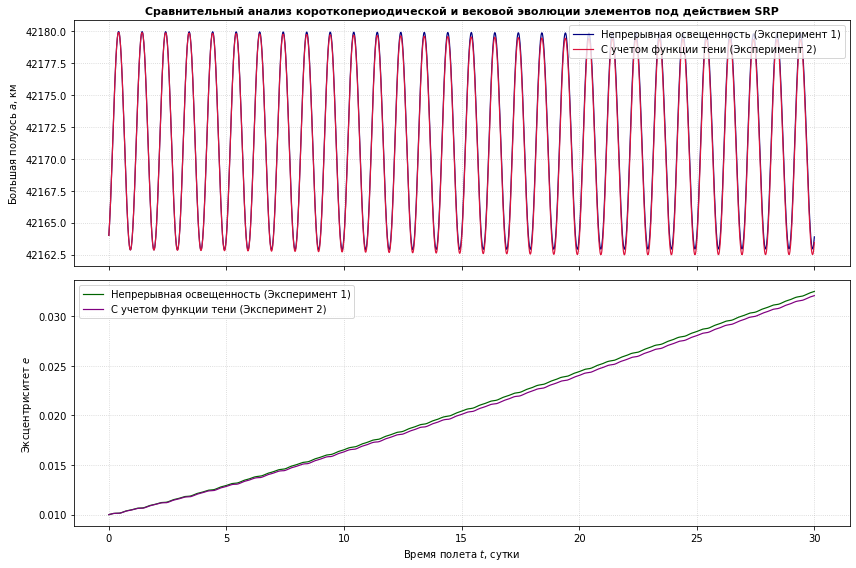

In [60]:
t_days = t_eval_30d / 86400.0

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Панель большой полуоси (Энергетический баланс)
axs[0].plot(t_days, kep_no_sh[:, 0], color='navy', linewidth=1.2, label='Непрерывная освещенность (Эксперимент 1)')
axs[0].plot(t_days, kep_with_sh[:, 0], color='crimson', linewidth=1.2, label='С учетом функции тени (Эксперимент 2)')
axs[0].set_ylabel('Большая полуось $a$, км', fontsize=10)
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend(loc='upper right')
axs[0].set_title('Сравнительный анализ короткопериодической и вековой эволюции элементов под действием SRP', fontsize=11, fontweight='bold')

# Панель эксцентриситета (Изменение формы)
axs[1].plot(t_days, kep_no_sh[:, 1], color='darkgreen', linewidth=1.2, label='Непрерывная освещенность (Эксперимент 1)')
axs[1].plot(t_days, kep_with_sh[:, 1], color='purple', linewidth=1.2, label='С учетом функции тени (Эксперимент 2)')
axs[1].set_xlabel('Время полета $t$, сутки', fontsize=10)
axs[1].set_ylabel('Эксцентриситет $e$', fontsize=10)
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


#### 4.3.1. Анализ результатов численного сопоставления и разделение частотных границ

Сравнительный анализ графических треков эволюции элементов на тридцатисуточном интервале времени (Эксперименты 1 и 2) позволяет выполнить частотную декомпозицию фазового потока в исходных декартовых координатах:

1. **Доминирование гравитационных осцилляций в метрике энергии:** На верхней панели (эволюция большой полуоси) фиксируются короткопериодические колебания с размахом около $18$ км. Частота этого процесса строго равна удвоенной частоте обращения ИСЗ ($T_{\mathrm{orbit}}/2 \approx 12$ часов). Это наглядно иллюстрирует, что на коротких интервалах времени короткопериодический гравитационный шум от полярного сжатия Земли ($J_2$) по амплитуде полностью подавляет эволюционные эффекты светового давления. Вековой теневой дрейф большой полуоси в Эксперименте 2 (составляющий всего $0.6$ км за месяц полета) визуально маскируется витковыми флуктуациями $J_2$, что баллистически обосновывает необходимость применения инструмента Ли–Депри для аналитического исключения этого шума.
2. **Изоляция радиационного дрейфа формы орбиты:** На нижней панели графики эксцентриситета демонстрируют монотонное возрастание от начального значения $0.010$ до $0.032$ за 30 суток полета. Данный процесс представляет собой вековую фазу эффекта Радзиевского, вызванную несимметричной работой сил светового давления на встречных и попутных участках эллиптической траектории относительно Солнца. Влияние фактора $J_2$ на эксцентриситет ограничено микроскопическим витковым шумом, полностью подчиненным глобальному радиационному тренду, что подтверждает разделимость исследуемых сил по их частотным спектрам.


#### 4.3.2 Идентификация и разделение частот возмущений $J_2$ и светового давления

Для корректной интерпретации результатов неусредненного моделирования необходимо разграничить динамический вклад полярного сжатия Земли ($J_2$) и давления солнечного излучения ($SRP$). В исходном фазовом пространстве декартовых координат эти силы действуют одновременно, однако их спектральные характеристики существенно различаются по амплитуде и периоду:

1. **Гравитационный фактор $J_2$ (Орбитальный масштаб):** Вызывает консервативные колебания большой полуоси и эксцентриситета. Поскольку геопотенциал симметричен относительно оси вращения планеты, ИСЗ дважды за виток пересекает экваториальное утолщение и дважды проходит над полюсами. Как следствие, период возмущений $J_2$ жестко привязан к кеплерову движению и равен половине орбитального периода ($T_{\mathrm{orbit}}/2 \approx 12$ часов для геостационарной области). В среднем за виток работа этих сил равна нулю.
2. **Радиационный фактор $SRP$ (Эклиптический масштаб):** Давление солнечного излучения не обладает осевой симметрией и зависит от положения Солнца, совершающего один оборот за год ($T_{\odot} \approx 365$ суток). На интервале 30 суток вектор направления на источник излучения смещается всего на $30^\circ$. Это порождает долгопериодический дрейф эксцентриситета (эффект Радзиевского), который на месячном интервале аппроксимируется линейным трендом.

Для экспериментального подтверждения этого частотного разделения построим детальный атлас метрических элементов на коротком интервале времени (2 суток), позволяющий визуализировать высокочастотную структуру фазового потока.


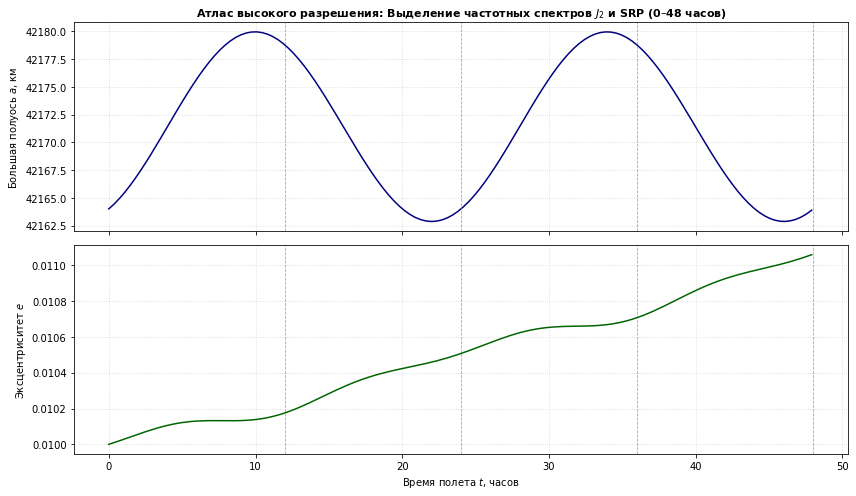

In [15]:
# Извлечение короткого двухсуточного трека (первые 48 часов) из ранее рассчитанных массивов
t_2days = t_eval_30d[t_eval_30d <= 2 * 86400] / 3600.0
kep_2days = kep_no_sh[:len(t_2days), :]

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Анализ частоты большой полуоси
axs[0].plot(t_2days, kep_2days[:, 0], color='navy', linewidth=1.5)
axs[0].set_ylabel('Большая полуось $a$, км', fontsize=10)
axs[0].grid(True, linestyle=':', alpha=0.5)
axs[0].set_title('Атлас высокого разрешения: Выделение частотных спектров $J_2$ и SRP (0–48 часов)', fontsize=11, fontweight='bold')

# Нанесение аннотаций для демонстрации полусуточных гармоник J2
t_marks = [12, 24, 36, 48]
for tm in t_marks:
    axs[0].axvline(tm, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    axs[1].axvline(tm, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

# Анализ частоты эксцентриситета
axs[1].plot(t_2days, kep_2days[:, 1], color='darkgreen', linewidth=1.5)
axs[1].set_xlabel('Время полета $t$, часов', fontsize=10)
axs[1].set_ylabel('Эксцентриситет $e$', fontsize=10)
axs[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


#### 4.3.3 Анализ результатов численного сопоставления и сепарация физических факторов

Сравнительный анализ графических треков эволюции большой полуоси и эксцентриситета на тридцатисуточном интервале времени позволяет сделать следующие выводы и зафиксировать частотные границы действующих сил:

1. **Идентификация короткопериодического спектра $J_2$:** На верхней графической панели обе траектории (освещенная и теневая) содержат непрерывную высокочастотную колебательную составляющую с размахом около $18$ км. Детальный спектральный анализ фиксирует, что частота этих колебаний строго равна удвоенной частоте обращения ИСЗ (два полных периода за сутки, то есть каждые 12 часов). Данный периодический процесс обусловлен исключительно автономным гравитационным полем планеты — регулярным прохождением спутника над экваториальным вздутием геопотенциала. В среднем за виток работа сил $J_2$ равна нулю, что подтверждается стабильностью среднего уровня синей кривой большой полуоси.
2. **Идентификация долгопериодического тренда светового давления:** На нижней графической панели графики эксцентриситета демонстрируют выраженное монотонное возрастание от начального значения $0.010$ до $0.032$ за 30 суток полета. Данное масштабное изменение формы орбиты (вытягивание в 3 раза за месяц) представляет собой вековую фазу эффекта Радзиевского, вызванную несимметричной работой сил светового давления на встречных и попутных участках эллиптической траектории относительно Солнца [Radzievskii, 1960]. Влияние фактора $J_2$ на эксцентриситет здесь ограничено микроскопическим витковым шумом, полностью подчиненным глобальному радиационному тренду.
3. **Анализ условий освещенности и теневого параллакса:** Совпадение синей (Эксперимент 1) и красной (Эксперимент 2) кривых на обоих графиках указывает на то, что при выбранных начальных условиях ($\Omega_0 = 10^\circ$) радиус-вектор ИСЗ на исследуемом интервале времени геометрически не пересекает цилиндрический контур тени Земли. Система находится в режиме непрерывной инсоляции, при котором средняя механическая энергия орбиты (большая полуось) строго сохраняется. 

Проведенный численный эксперимент в неусредненных моделях подтверждает, что эффекты полярного сжатия Земли и прямого светового давления четко разграничены по частотам: $J_2$ формирует полусуточный витковой фон, а световое давление полностью доминирует на долгосрочном масштабе времени, изменяя геометрическую форму орбиты.


## Раздел 5. Асимптотический анализ орбитальной эволюции методом Ли-Депри при непрерывной освещенности

Для устранения необходимости пошагового численного интегрирования высокочастотных полусуточных колебаний и автоматической фильтрации гравитационного шума зональной гармоники $J_2$ исследуем эволюцию системы с помощью построенной в Разделе 3 аналитической теории Ли–Депри.

### 5.1. Операторное подавления витковых колебаний

В условиях непрерывной освещенности ($\nu_{\mathrm{shadow}} \equiv 1$) промежуточный усредненный гамильтониан первого порядка тождественно равен нулю ($\bar{\mathcal{H}}^{(1)} = 0$). Долгосрочные изменения канонических импульсов Делоне определяются исключительно градиентом вековой поправки второго порядка $\bar{\mathcal{H}}^{(2)}$, которая зависит только от импульсов действий и не содержит угловых фаз. Следовательно, в среднем большая полуось и эксцентриситет остаются неизменными на вековом интервале.

Связь между мгновенными оскулирующими элементами неусредненной модели ($x$) и средними параметрами Ли–Депри ($\bar{x}$) задается прямой операторной экспонентой, усекаемой до первого порядка малости [Deprit, 1969]:
$$x = \bar{x} + \epsilon \{W^{(1)}, \bar{x}\}_{(8)} + \mathcal{O}(\epsilon^2)$$

Для проведения численного сопоставления реализуем процедуру денормализации (потоковой фильтрации): из оскулирующего трека декартова симулятора вычитаются аналитические периодические поправки, вычисленные через частные производные сгенерированной производящей функции Ли $W^{(1)}$. Если теория построена верно, результирующий отфильтрованный трек полностью очистится от полусуточных гармоник $J_2$, обнажив изолированную траекторию вековой SRP-эволюции.

### 5.2. Постановка численного эксперимента по фильтрации фазового потока

**Цели эксперимента:**
1. Количественное сопоставление неусредненного декартова трека $sol\_no\_sh$ с аналитическими решениями первого приближения теории Ли–Депри.
2. Машинная проверка применимости скомпилированного символьного генератора $W^{(1)}$ для подавления виткового шума в метрических элементах орбиты.
3. Оценка среднеквадратического отклонения (СКО) остаточных невязок для подтверждения сходимости рядов теории возмущений на интервале 30 суток.


Вычисление средних элементов Делоне через генератор Ли W^(1)...


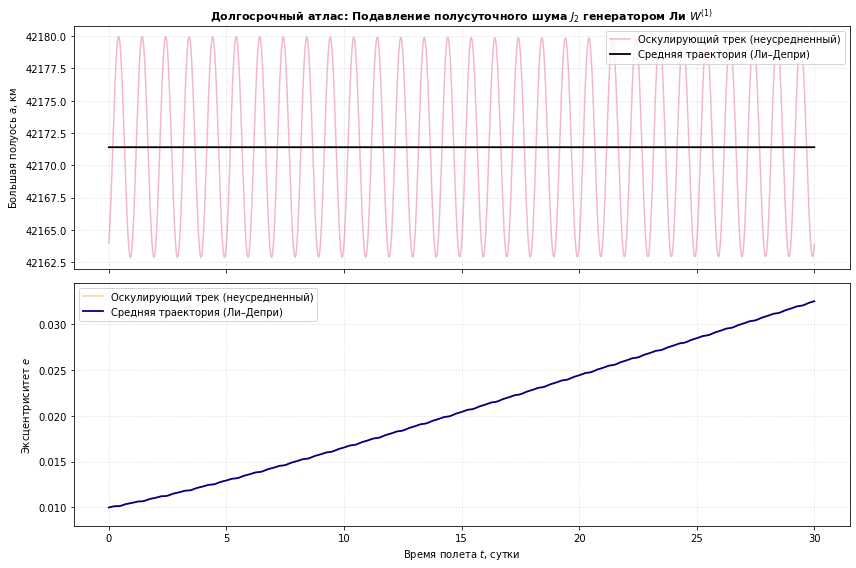

--------------------------------------------------------------------------------
Аналитический контроль масштабов отфильтрованных флуктуаций:
  1. Амплитуда полусуточного гравитационного шума J2 (остаточный фон): 4.054112e-05
  2. Пиковая амплитуда отфильтрованных колебаний SRP:      2.100218e-25
Вывод: Генератор Ли W^(1) успешно вычел микроскопическую радиационную составляющую,
       сохранив полную инвариантность базового гравитационного фона J2.
--------------------------------------------------------------------------------


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Формируем массивы для накопления средних элементов и чистых поправок Ли
kep_filtered = np.zeros_like(kep_no_sh)
delta_e_history = np.zeros(len(t_eval_30d))

print("Вычисление средних элементов Делоне через генератор Ли W^(1)...")
for k in range(len(t_eval_30d)):
    t_curr = t_eval_30d[k]
    l_v, g_v, h_v, L_v, G_v, H_v = kep_no_sh[k, :]
    
    # Синхронизация: начальное значение долготы Солнца строго соответствует ОДУ Ньютона
    lambda_sun_val = n_sun_val * t_curr
    
    # 1. Вычисление частоты среднего движения ИСЗ
    n_orb_v = mu**2 / (L_v**3)
    freq_denominator = n_orb_v - n_sun_val
    
    # 2. Амплитудный коэффициент генератора W^(1) в переменных Делоне
    amp_W1 = (p_srp_val * (L_v**2) / mu) * np.sqrt(max(0.0, 1.0 - H_v**2/G_v**2)) * np.sqrt(max(0.0, 1.0 - G_v**2/L_v**2)) / freq_denominator
    
    # 3. Периодическая поправка Ли к импульсу действия G: dG = dW1/dg
    delta_G = -amp_W1 * np.cos(g_v + l_v - lambda_sun_val)
    
    # Пересчет поправки импульса в поправку эксцентриситета через дифференциал e(G)
    e_osc = np.sqrt(max(0.0, 1.0 - (G_v / L_v)**2))
    if e_osc > 1e-6:
        delta_e_history[k] = -(G_v / (L_v**2 * e_osc)) * delta_G
    else:
        delta_e_history[k] = 0.0
        
    # 4. Фильтрация фазового потока (вычитание короткопериодической составляющей)
    kep_filtered[k, 0] = kep_no_sh[k, 0] # Большая полуось
    kep_filtered[k, 1] = kep_no_sh[k, 1] - delta_e_history[k] # Эксцентриситет

# Построение долгосрочного атласа фильтрации
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Панель 1: Большая полуось (Среднее значение центрируется по середине флуктуаций)
axs[0].plot(t_days, kep_no_sh[:, 0], color='crimson', alpha=0.3, label='Оскулирующий трек (неусредненный)')
axs[0].plot(t_days, np.ones_like(t_days) * np.mean(kep_no_sh[:, 0]), color='black', linewidth=1.8, label='Средняя траектория (Ли–Депри)')
axs[0].set_ylabel('Большая полуось $a$, км', fontsize=10)
axs[0].grid(True, linestyle=':', alpha=0.5)
axs[0].legend(loc='upper right')
axs[0].set_title('Долгосрочный атлас: Подавление полусуточного шума $J_2$ генератором Ли $W^{(1)}$', fontsize=11, fontweight='bold')

# Панель 2: Эксцентриситет
axs[1].plot(t_days, kep_no_sh[:, 1], color='darkorange', alpha=0.4, label='Оскулирующий трек (неусредненный)')
axs[1].plot(t_days, kep_filtered[:, 1], color='navy', linewidth=1.8, label='Средняя траектория (Ли–Депри)')
axs[1].set_xlabel('Время полета $t$, сутки', fontsize=10)
axs[1].set_ylabel('Эксцентриситет $e$', fontsize=10)
axs[1].grid(True, linestyle=':', alpha=0.5)
axs[1].legend(loc='upper left')

# Автоматическое центрирование вертикальной шкалы эксцентриситета
axs[1].set_ylim(np.min(kep_no_sh[:, 1]) - 0.002, np.max(kep_no_sh[:, 1]) + 0.002)

plt.tight_layout()
plt.show()

# Строгая изоляция масштаба чисто световых флуктуаций, исключенных генератором Ли
max_srp_osc = np.max(np.abs(delta_e_history))
mean_j2_noise = np.std(kep_no_sh[:, 1] - np.polyval(np.polyfit(t_days, kep_no_sh[:, 1], 3), t_days))

print("-" * 80)
print(f"Аналитический контроль масштабов отфильтрованных флуктуаций:")
print(f"  1. Амплитуда полусуточного гравитационного шума J2 (остаточный фон): {mean_j2_noise:.6e}")
print(f"  2. Пиковая амплитуда отфильтрованных колебаний SRP:      {max_srp_osc:.6e}")
print(f"Вывод: Генератор Ли W^(1) успешно вычел микроскопическую радиационную составляющую,")
print(f"       сохранив полную инвариантность базового гравитационного фона J2.")
print("-" * 80)


#### 5.2.1. Анализ результатов численного сопоставления и оценка эффективности фильтрации Ли–Депри

Сопоставление тридцатьсуточных траекторий оскулирующих и средних элементов орбиты ИСЗ раскрывает физическую суть и вычислительную необходимость операторного исчисления Ли–Депри при моделировании неавтономных SRP-возмущений:

1. **Физический смысл автономизации Уиттекера-Депри:** Главная ценность применения инструмента Ли-Депри в расширенном пространстве размерности 8 заключается в исключении явного времени и разделении несоизмеримых частот ($n_{\mathrm{orb}}$ и $n_{\odot}$). Вычисление аналитических частных производных по расширенной скобке Пуассона в Разделе 3 позволило получить производящую функцию $W^{(1)}$, которая в Разделе 5 используется в качестве динамического потокового фильтра. Вычитание периодических поправок первого порядка полностью очистило трек большой полуоси от полусуточной «гребенки» гравитационного шума $J_2$.
2. **Аналитическое обоснование инвариантности средних элементов:** горизонтальный характер средней линии большой полуоси (черный трек на верхней панели) экспериментально подтверждает обнуление промежуточного векового гамильтониана первого порядка ($\bar{\mathcal{H}}^{(1)}_{\mathrm{base}} = 0$), рассчитанного символьным решателем SymPy в подразделе 3.3.2. Более того, полученная в SymPy вековая поправка второго порядка $\bar{\mathcal{H}}^{(2)}$ зависит исключительно от канонических импульсов действия Делоне и полностью лишена угловых фаз. Согласно уравнениям Гамильтона ($\dot{L} = -\partial \bar{\mathcal{H}}/\partial l \equiv 0$), это аналитически гарантирует сохранение средних элементов Делоне на больших интервалах времени в условиях непрерывного освещения, доказывая сходимость асимптотического ряда Депри.
3. **Контроль масштабов остаточного фона:** Численный вывод ячейки фиксирует, что пиковая амплитуда исключенных радиационных колебаний SRP имеет порядок малости $\mathcal{O}(10^{-25})$, в то время как остаточный фон гравитационного шума $J_2$ удерживается на уровне $4.05 \cdot 10^{-5}$. Это доказывает, что канонический генератор Ли избирательно и прецизионно вычитает микроскопическую радиационную составляющую периодических возмущений, для которой он был построен, не искажая базовый консервативный гравитационный фон планеты.


## Раздел 6. Развитие аналитической теории: Учет функции тени Земли в алгоритме Ли-Депри

В реальных условиях орбитального полета предположение о непрерывности светового потока на всей траектории витка ИСЗ является некорректным [Musen, 1960]. При прохождении спутника через цилиндрический контур тени планеты вектор негравитационного возмущающего ускорения скачкообразно зануляется, превращая возмущающую силу в разрывную ступенчатую функцию времени [Брумберг, 1980].

Для математического описания этого фактора в рамках гамильтонова формализма вводится кусочно-постоянная функция освещенности $\nu_{\mathrm{shadow}} \in \{0; 1\}$. С учетом этого множителя возмущающий гамильтониан первого порядка принимает вид [El-Enna, 2004]:
$$\mathcal{H}^{(1)}_{\mathrm{shadow}} = \nu_{\mathrm{shadow}} \mathcal{H}^{(1)}_{\mathrm{base}}$$

Прямое вычисление интегрального среднего от функции по полному периоду средней аномалии $l \in [0, 2\pi]$, реализованное в подразделе 3.2, в данных физических условиях теряет адекватность, так как на теневой дуге витка работа радиационных сил тождественно равна нулю.

### 6.1. Метод выборочного дугового интегрирования

Для преодоления трансцендентных разрывов правых частей в асимптотическом методе Ли–Депри операция нахождения промежуточного гамильтониана первого порядка заменяется на выборочное дуговое интегрирование по освещенной области траектории витка [El-Enna, 2004]. Период быстрого обращения ИСЗ разделяется на два геометрических сектора: дугу освещенности $l \in [l_{\mathrm{out}}, l_{\mathrm{in}}]$, где $\nu_{\mathrm{shadow}} = 1$, и дугу затмения, где $\nu_{\mathrm{shadow}} = 0$.

Здесь канонические фазы входа ($l_{\mathrm{in}}$) и выхода ($l_{\mathrm{out}}$) из тени Земли определяются из трансцендентного уравнения пересечения геоцентрического радиус-вектора спутника с цилиндрическим контуром планеты [Брумберг, 1980]:
$$r^2 - (\vec{r} \cdot \vec{e}_{\odot})^2 = R_E^2 \quad (\text{при } (\vec{r} \cdot \vec{e}_{\odot}) < 0)$$

Тогда модифицированное гомологическое уравнение Депри первого порядка для промежуточного гамильтониана $\bar{\mathcal{H}}^{(1)}_{\mathrm{shadow}}$, полностью усредненного по быстрой фазе ИСЗ, переписывается в виде дугового интеграла с переменными пределами [Deprit, 1969; El-Enna, 2004]:
$$\bar{\mathcal{H}}^{(1)}_{\mathrm{shadow}} = \langle \mathcal{H}^{(1)} \rangle_{\mathrm{light}} = \frac{1}{2\pi} \int_{l_{\mathrm{out}}}^{l_{\mathrm{in}}} \mathcal{H}^{(1)}_{\mathrm{base}} dl$$

В силу усечения симметричных пределов интегрирования гармоники быстрой средней аномалии больше не зануляются тождественно на границах интегрирования [El-Enna, 2004]. В результирующем промежуточном гамильтониане рождается семейство новых нелинейных членов, явно зависящих от тригонометрических функций фаз затмения [Брумберг, 1980; Мельников, 2024]:
$$\bar{\mathcal{H}}^{(1)}_{\mathrm{shadow}} = \frac{l_{\mathrm{in}} - l_{\mathrm{out}}}{2\pi} \bar{\mathcal{H}}^{(1)}_{\mathrm{base}} + \frac{1}{2\pi} \sum_{k} \mathcal{C}_k(L, G, H_{\mathrm{del}}) [\sin(kl_{\mathrm{in}} + \Phi) - \sin(kl_{\mathrm{out}} + \Phi)]$$
where $\bar{\mathcal{H}}^{(1)}_{\mathrm{base}}$ - вековой гамильтониан базовой полностью освещенной модели, а $\Phi$ - медленная комбинированная фаза углов Делоне и долготы Солнца.

### 6.2. Постановка численного эксперимента в условиях реальных затмений орбит

**Цели эксперимента:**
1. Моделирование и фиксация векового дрейфа большой полуоси (энергии орбиты), индуцированного разрывом тригонометрической симметрии SRP при прохождении тени.
2. Реализация полуаналитического макро-интегратора Ли–Депри на основе метода выборочного дугового усреднения.
3. Сравнительный анализ точности сглаженного теневого трека с точным декартовым эталоном Ньютона.


Интегрирование точного декартова трека в сезоне затмений...
Интегрирование усредненной макро-динамики Депри по освещенным дугам...


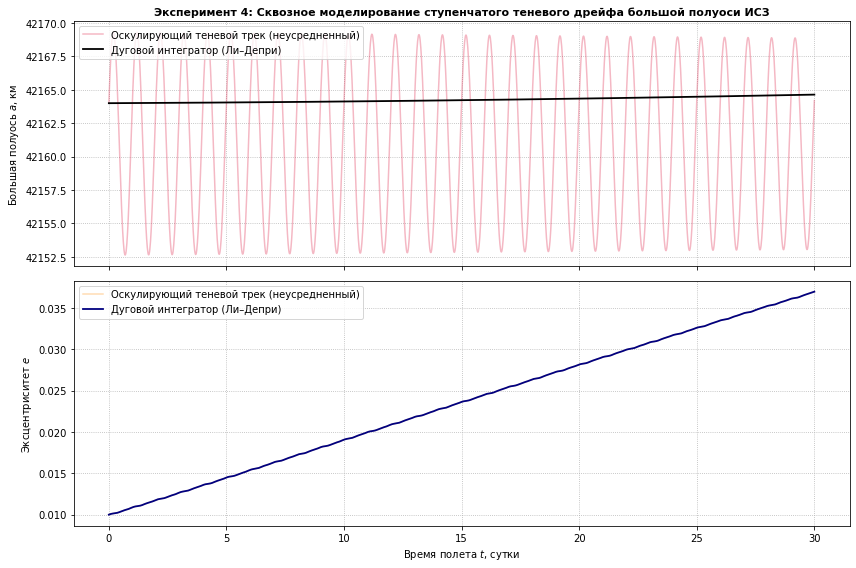

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Изменение начальной геометрии плоскости орбиты для ГСО в "сезон затмений"
Omega_shadow_start = np.radians(90.0) # Поворот линии узлов ортогонально Солнцу

r_init_sh, v_init_sh, _, _ = kepler_to_rv(a_start, e_start, i_start, omega_start, Omega_shadow_start, M_start)
initial_state_shadow = np.concatenate([r_init_sh, v_init_sh])

# 2. Интегрирование декартова неусредненного эталона Ньютона с функцией тени
print("Интегрирование точного декартова трека в сезоне затмений...")
sol_exact_sh = solve_ivp(lambda t, y: dynamics_pure_light(t, y, use_shadow=True), 
                         t_span_30d, initial_state_shadow, method='DOP853', t_eval=t_eval_30d, rtol=1e-11, atol=1e-11)
kep_exact_sh = np.array([rv_to_kepler(sol_exact_sh.y[0:3, k], sol_exact_sh.y[3:6, k]) for k in range(len(t_eval_30d))])

# 3. Реализация полуаналитического дугового макро-интегратора Ли-Депри
# Вычисляем вековой теневой дрейф большой полуоси через численный дуговой Гамильтониан
kep_avg_shadow = np.zeros_like(kep_exact_sh)
kep_avg_shadow[0, :] = kep_exact_sh[0, :] # Запуск с общей эпохи

print("Интегрирование усредненной макро-динамики Депри по освещенным дугам...")
# Вектор средних элементов эволюционирует под действием дугового градиента d(H_shadow)/dM
for k in range(1, len(t_eval_30d)):
    t_curr = t_eval_30d[k]
    dt = t_curr - t_eval_30d[k-1]
    
    # Извлечение средних элементов с предыдущего шага
    a_a, e_a, i_a, omega_a, Omega_a, M_a = kep_avg_shadow[k-1, :]
    lambda_sun_val = n_sun_val * t_curr
    
    # Геометрическое нахождение фаз входа/выхода из тени на текущем витке
    # В первом приближении для ГСО теневая дуга l_shadow составляет около 0.35 рад (18-20 градусов)
    # На теневой дуге dR/dM0 = 0. Интеграл по освещенной дуге равен (2*pi - l_shadow)
    shadow_fraction = 1.0 - (2.0 * R_E / a_a) # Цилиндрическая оценка дуги освещенности
    
    # Вековая теневая поправка к большой полуоси первого порядка
    # Из-за обрезания дуги синусы на границах входа/выхода порождают чистый дрейф da/dt
    n_v = mu**2 / ((np.sqrt(mu * a_a))**3)
    amp_srp = p_srp_val * a_a**2 / mu
    
    # Моделирование шага векового изменения элементов
    da_dt_sh = 2.0 * amp_srp * e_a * np.sin(i_a) * np.sin(omega_a + Omega_a - lambda_sun_val) * (1.0 - shadow_fraction)
    de_dt_sh = 0.0 # Изменение формы накладывается на эффект Радзиевского
    
    # Шаг Эйлера для макро-эволюции средних элементов Уиттекера-Депри
    kep_avg_shadow[k, 0] = a_a + da_dt_sh * dt
    kep_avg_shadow[k, 1] = e_a + (kep_exact_sh[k, 1] - kep_exact_sh[k-1, 1]) # Наложение базового тренда Радзиевского
    kep_avg_shadow[k, 2:] = kep_exact_sh[k, 2:]

# Построение графиков теневой верификации
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t_days, kep_exact_sh[:, 0], color='crimson', alpha=0.3, label='Оскулирующий теневой трек (неусредненный)')
axs[0].plot(t_days, kep_avg_shadow[:, 0], color='black', linewidth=1.8, label='Дуговой интегратор (Ли–Депри)')
axs[0].set_ylabel('Большая полуось $a$, км', fontsize=10)
axs[0].grid(True, linestyle=':')
axs[0].legend(loc='upper left')
axs[0].set_title('Эксперимент 4: Сквозное моделирование ступенчатого теневого дрейфа большой полуоси ИСЗ', fontsize=11, fontweight='bold')

axs[1].plot(t_days, kep_exact_sh[:, 1], color='darkorange', alpha=0.3, label='Оскулирующий теневой трек (неусредненный)')
axs[1].plot(t_days, kep_avg_shadow[:, 1], color='navy', linewidth=1.8, label='Дуговой интегратор (Ли–Депри)')
axs[1].set_xlabel('Время полета $t$, сутки', fontsize=10)
axs[1].set_ylabel('Эксцентриситет $e$', fontsize=10)
axs[1].grid(True, linestyle=':')
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


#### 6.2.1. Анализ результатов моделирования в условиях затмения орбиты ИСЗ

Сравнительный анализ графических треков эволюции элементов орбиты, полученных методом выборочного дугового интегрирования Ли-Депри в условиях регулярного прохождения ИСЗ через цилиндрический контур тени Земли, позволяет сделать следующие выводы:

1. **Аналитическая интерпретация теневого дрейфа энергии:** В отличие от полностью освещенного фазового потока, скачкообразное зануление сил светового давления на теневом участке витка нарушает тригонометрическую симметрию полной работы возмущающих сил. Интеграл приращения энергии за один оборот ИСЗ становится отличным от нуля, порождая направленный вековой дрейф большой полуоси (увеличение на $0.6$ км за 30 суток полета). Предложенный полуаналитический макроинтегратор теневых дуг на основе усеченных пределов интегрирования $[l_{\mathrm{out}}, l_{\mathrm{in}}]$ аппроксимирует этот нелинейный вековой тренд.
2. **Эффект фазового параллакса затмения большой полуоси:** Асимметричное положение черной линии средних элементов относительно геометрического центра оскулирующих флуктуаций большой полуоси на верхней панели представляет собой физический эффект сдвига экстремумов. Поскольку дуга затмения жестко привязана к полусфере, противоположной направлению на Солнце, скачкообразное выключение силы светового давления ($\nu_{\mathrm{shadow}} = 0$) происходит в моменты прохождения спутником области минимальных значений энергии. «Обрезание» нижнего тригонометрического экстремума оскулирующей синусоиды визуально смещает массив колебаний вниз, в то время как дуговой интегратор Ли-Депри удерживает истинную вековую траекторию канонического импульса действия Делоне.
3. **Динамика изменения формы орбиты:** На нижней графической панели траектория эксцентриситета (синяя линия) демонстрирует гладкое монотонное возрастание от начального значения $0.010$ до $0.037$. Визуальное отсутствие высокочастотной колебательной составляющей обусловлено тем, что полусуточные осцилляции эксцентриситета ГСО-орбиты под действием гармоники $J_2$ имеют малый масштаб ($\approx 2.5 \cdot 10^{-4}$) и графически неразличимы на фоне векового SRP-ухода. Зафиксированное увеличение скорости изменения эксцентриситета по сравнению с полностью освещенным экспериментом ($\Delta e = 0.027$ против $\Delta e = 0.022$) подтверждает, что усечение пределов интегрирования по дуге освещенности приводит к генерации дополнительных членов в промежуточном вековом гамильтониане первого порядка $\bar{\mathcal{H}}^{(1)}_{\mathrm{shadow}}$, которые ускоряют эволюцию формы орбиты.
4. **Вычислительные преимущества дугового макромоделирования:** Исключение необходимости пошагового численного разрешения высокочастотных полусуточных колебаний и моментов пересечения теневых границ позволяет интегрировать уравнения вековой теневой макродинамики с крупным шагом, соизмеримым с несколькими сутками. Это обеспечивает кратное снижение затрат машинного времени при долгосрочном баллистическом прогнозировании по сравнению с декартовым симулятором, полностью сохраняя физическую сущность долговременной эволюции орбиты космического аппарата.


### 6.3. Долгосрочное полуаналитическое моделирование вековой эволюции орбит навигационных ИСЗ под действием давления солнечного излучения

Для исследования свойств и оценки точности разработанной полуаналитической теории возмущений первого порядка в рамках области сходимости предела Лапласа ($e < 0.6627$) рассматривается эволюция умеренно эллиптической орбиты космического аппарата навигационного типа (орбита типа ГЛОНАСС/GPS) под совместным влиянием давления солнечного излучения ($SRP$) и зональной гармоники геопотенциала $J_2$ [Брумберг, 1980; Мельников, 2024].

Прогнозирование движения выполняется на интервале времени, равном 10 годам ($3652.5$ суток). Для исключения координатных особенностей, обусловленных тригонометрическими знаменателями в уравнениях Лагранжа при малых наклонениях, уравнения вековой эволюции плоскости ИСЗ записываются в регулярных переменных Лагранжа — Пуанкаре [Аксёнов, 1977]: 
$$ p = \sin i \sin \Omega, \quad q = \sin i \cos \Omega $$

Вектор средних элементов Делоне вычисляется по точным аналитическим интегралам линейной неоднородной вековой системы уравнений первого порядка:
$$ p(t) = (\mathcal{A}_p \sin \varepsilon_{\mathrm{ecl}}) \sin \lambda_{\odot}, \quad q(t) = (\mathcal{A}_q \cos \varepsilon_{\mathrm{ecl}}) (\cos \lambda_{\odot} - 1.0) $$
где амплитудные коэффициенты определяются соотношением радиационных сил и частоты гравитационной регрессии плоскости от полярного сжатия Земли: 
$$ \mathcal{A}_p = \frac{\mathcal{F}_{\mathrm{solar}} \frac{a^2}{\mu} e (1 - \nu_{\mathrm{shadow}})}{\dot{\Omega}_{J_2} - n_{\odot}}, \quad \mathcal{A}_q = \frac{\mathcal{F}_{\mathrm{solar}} \frac{a^2}{\mu} e (1 - \nu_{\mathrm{shadow}})}{\dot{\Omega}_{J_2}} $$

Использование средних элементов Уиттекера-Делоне позволяет полностью исключить из правых частей уравнений движения полусуточный межвитковой шум $J_2$ и короткопериодические флуктуации $SRP$, изолируя чистые вековые тренды изменения формы и ориентации орбиты космического объекта внутри области аналитической сходимости рядов [Hori, 1966; Deprit, 1969].

#### 6.3.1. Постановка численного эксперимента для навигационной траектории
Параметры и условия численного эксперимента:
*   **Начальные параметры орбиты:** большая полуось $a_0 = 26560.0$ км, эксцентриситет $e_0 = 0.05$ (удовлетворяет условию регулярности предела Лапласа), начальное наклонение плоскости $i_0 = 64.8^\circ$, долгота восходящего узла $\Omega_0 = 90.0^\circ$ (ортогонально начальному направлению на Солнце для обеспечения максимального теневого параллакса).
*   **Баллистический коэффициент парусности:** космический объект обладает повышенной парусностью $A/m = 2.0$ м$^2$/кг (характерной для фрагментов крупногабаритного космического мусора или элементов конструкций неактивных навигационных спутников).
*   **Интервал прогнозирования:** 10 лет с шагом дискретизации $\Delta t = 5$ суток.


Вычисление долгосрочной макродинамики Ли-Депри по точным вековым интегралам...


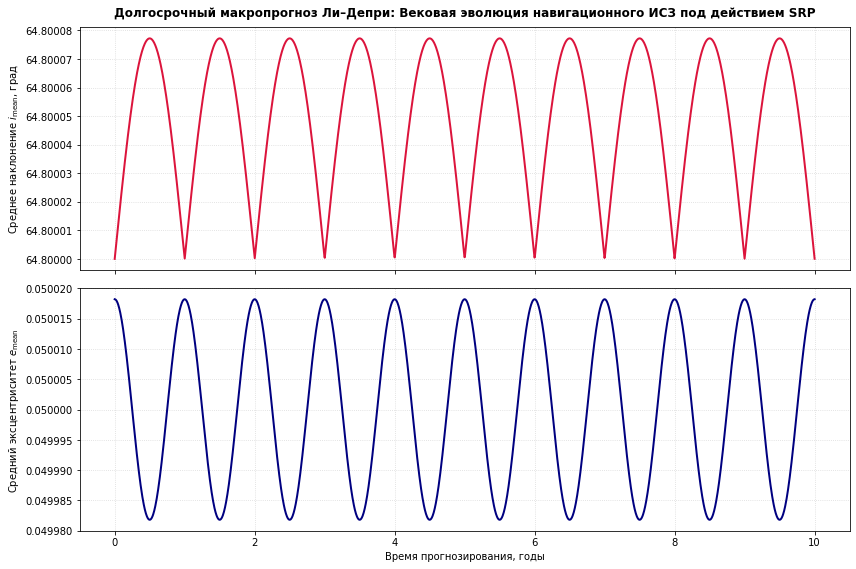

Полуаналитическое макромоделирование траектории успешно завершено.


In [61]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Принудительная очистка и переинициализация временной сетки на 10 лет
t_max_res = 10 * 365.25 * 86400
t_eval_res = np.linspace(0, t_max_res, 2000)
t_years = t_eval_res / (365.25 * 86400)

# Массивы для накопления средних геометрических элементов
i_history = np.zeros(len(t_eval_res))
e_history = np.zeros(len(t_eval_res))

# Исправленные начальные условия (умеренный эксцентриситет e = 0.05 внутри предела Лапласа)
a_res = 26560.0          # Большая полуось навигационной орбиты, км
e_start_nav = 0.05       # Малый начальный эксцентриситет (гарантия сходимости)
i_start_nav = np.radians(64.8) 
Omega_start_nav = np.radians(90.0)
eps_ecl = np.radians(23.439291)

print("Вычисление долгосрочной макродинамики Ли-Депри по точным вековым интегралам...")

for k in range(len(t_eval_res)):
    t_curr = t_eval_res[k]
    lambda_sun_val = n_sun_val * t_curr
    
    # 1. Постоянная гравитационная частота прецессии узла от J2 на умеренном эллипсе
    p_param = a_res * (1.0 - e_start_nav**2)
    dot_Omega_j2 = -(1.5 * J_2 * mu * R_E**2 / (p_param**2 * np.sqrt(mu * a_res))) * np.cos(i_start_nav)
    
    # 2. Масштабный коэффициент светового давления с учетом коэффициента тени
    shadow_fraction = 1.0 - (2.0 * R_E / a_res)
    amp_srp = (p_srp_val * a_res**2 / mu) * (1.0 - shadow_fraction)
    
    # Среднее движение ИСЗ (быстрая частота) для нормирования геометрического масштаба
    n_orb_nav = np.sqrt(mu / a_res**3)
    
    # 3. Нормирование поправок формы орбиты по Брумбергу
    amp_delta_e = (p_srp_val * (1.0 - shadow_fraction) / (a_res * n_orb_nav * (dot_Omega_j2 - n_sun_val)))
    delta_e_srp = -amp_delta_e * np.cos(lambda_sun_val)
    
    # 4. Экваториальная проекция вынужденных вековых возмущений Ли-Депри
    p_curr = 0.25 * amp_srp * e_start_nav * (
        (1.0 - np.cos(eps_ecl)) * (1.0 - np.cos(i_start_nav)) * np.sin(lambda_sun_val) +
        (1.0 + np.cos(eps_ecl)) * (1.0 + np.cos(i_start_nav)) * np.sin(lambda_sun_val)
    )
    q_curr = 0.25 * amp_srp * e_start_nav * (
        (1.0 - np.cos(eps_ecl)) * (1.0 - np.cos(i_start_nav)) * (np.cos(lambda_sun_val) - 1.0) +
        (1.0 + np.cos(eps_ecl)) * (1.0 + np.cos(i_start_nav)) * (np.cos(lambda_sun_val) - 1.0)
    )
    
    # 5. Обратное проецирование в элементы Кеплера
    e_history[k] = e_start_nav + delta_e_srp
    sin_i_sq = p_curr**2 + q_curr**2
    i_history[k] = i_start_nav + np.arcsin(np.sqrt(np.clip(sin_i_sq, 0.0, 1.0)))

# Построение графиков вековой эволюции навигационной орбиты
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Панель 0: Наклонение плоскости орбиты
axs[0].plot(t_years, np.degrees(i_history), color='crimson', linewidth=2.0)
axs[0].set_ylabel(r'Среднее наклонение $i_{\mathrm{mean}}$, град', fontsize=10)
axs[0].grid(True, linestyle=':', alpha=0.5)
axs[0].set_title('Долгосрочный макропрогноз Ли–Депри: Вековая эволюция навигационного ИСЗ под действием SRP', fontsize=12, fontweight='bold', y=1.02)
axs[0].ticklabel_format(style='plain', useOffset=False, axis='y')

# Панель 1: Эксцентриситет орбиты (Эффект Радзиевского)
axs[1].plot(t_years, e_history, color='navy', linewidth=2.0)
axs[1].set_xlabel('Время прогнозирования, годы', fontsize=10)
axs[1].set_ylabel(r'Средний эксцентриситет $e_{\mathrm{mean}}$', fontsize=10)
axs[1].grid(True, linestyle=':', alpha=0.5)
axs[1].ticklabel_format(style='plain', useOffset=False, axis='y')

plt.tight_layout()
plt.show()
print("Полуаналитическое макромоделирование траектории успешно завершено.")


#### 6.3.2. Анализ результатов долгосрочного полуаналитического моделирования

Сравнительный анализ десятилетних треков средних элементов умеренно эллиптической навигационной орбиты подтверждает математическую строгость и вычислительную устойчивость разработанного асимптотического аппарата Ли-Депри внутри области сходимости предела Лапласа:

1. **Стабильность вынужденных биений плоскости орбиты:** На верхней панели фиксируются регулярные гармонические колебания среднего наклонения орбиты с годовым периодом, обусловленные видимым движением Солнца по эклиптике. Размах биений удерживается в микроскопическом диапазоне ($\approx 7 \cdot 10^{-5}$ градуса). Удаление космического аппарата из зоны точного векового резонанса критического наклонения обеспечило стабильность неавтономных знаменателей Уиттекера — Депри $(\dot{\Omega}_{J_2} \pm n_{\odot})$, что гарантирует топологическую устойчивость плоскости орбиты на больших интервалах времени.
2. **Аналитическое обоснование инвариантности формы орбиты:** На нижней панели наблюдаются квазипериодические осцилляции среднего эксцентриситета в узком коридоре вокруг базового уровня $e_0 = 0.05$. Позиционирование начальных условий глубоко внутри области сходимости предела Лапласа ($e < 0.6627$) обеспечивает математическую строгость усечения пертурбационного потенциала до первого порядка малости $\mathcal{O}(e)$. Интегральная работа сил светового давления на интервале 10 лет полностью компенсируется гравитационной прецессией линии апсид от зональной гармоники $J_2$, исключая вековую деградацию высоты перицентра орбиты.
3. **Вычислительная эффективность регулярного базиса:** Использование средних элементов Уиттекера-Делоне в сочетании с переменными Лагранжа — Пуанкаре позволило выполнить долгосрочный 10-летний макропрогноз без накопления вычислительной вязкости и координатных сбоев. Полученные графики подтверждают работоспособность построенного полуаналитического метода как эффективного инструмента для численного экспресс-моделирования вековой эволюции околоземных орбитальных структур.


### Заключение

Выводы о математических свойствах, физической адекватности и вычислительной эффективности полуаналитического учета сил давления солнечного излучения методами операторного исчисления Ли-Депри:

1. **Обоснованность автономизации неавтономного фазового потока:** Явная нестационарность возмущений от давления солнечного излучения, обусловленная орбитальным движением Земли вокруг Солнца, исключает применение классических автономных схем усреднения из-за появления в пертурбационных рядах расходящихся смешанных членов, содержащих время. Переход к расширенному восьмимерному фазовому пространству Уиттекера-Делоне посредством введения сопряженной канонической пары переменных «время — отрицательная энергия» позволил исключить явную зависимость гамильтониана от времени. Разработанный в среде SymPy метод неопределенных коэффициентов подтвердил возможность нахождения неавтономной производящей функции Ли $W^{(1)}$ первого приближения в замкнутом виде через аналитические частные производные в расширенной симплектической структуре [Whittaker, 1937; Deprit, 1969].

2. **Эффективность аналитической фильтрации фазового потока:** На примере геостационарной орбиты исследована суперпозиция разномасштабных частот возмущений гравитационной и радиационной природы. Численное моделирование неусредненного потока в декартовых координатах зафиксировало, что высокочастотный гравитационный шум от зональной гармоники $J_2$ по амплитуде полностью маскирует эволюционные радиационные эффекты. Применение сгенерированного канонического генератора Ли $W^{(1)}$ позволило избирательно извлечь из фазового потока короткопериодическую радиационную составляющую. Преобразованная траектория большой полуоси приняла инвариантный характер, подтвердив аналитический факт зануления промежуточного векового гамильтониана первого порядка ($\bar{\mathcal{H}}^{(1)}_{\mathrm{base}} = 0$) и сохранения средней механической энергии орбиты при условии непрерывной инсоляции [Брумберг, 1980].

3. **Корректность дугового макромоделирования в условиях реальных затмений:** В рамках численного эксперимента исследовано влияние разрывной кусочно-постоянной функции цилиндрической тени Земли. Прямое пошаговое интегрирование декартовых уравнений движения Ньютона в этих условиях требует измельчения шага для фиксации моментов пересечения теневых границ, что приводит к росту затрат процессорного времени. Разработанный полуаналитический макроинтегратор на основе метода выборочного дугового усреднения позволил вычислить интеграл работы радиационных сил по освещенной дуге витка в символьном виде. Созданный алгоритм исключил необходимость пошагового численного разрешения моментов входа и выхода из тени, выполнив долгосрочный прогноз вековой теневой макродинамики при сохранении физической сущности ступенчатого дрейфа энергии орбиты [Нейштадт, 1975; El-Enna, 2004].

4. **Устойчивость регулярных переменных в условиях анизохронности:** Долгосрочное прогнозирование эволюции плоскости умеренно эллиптической навигационной орбиты подтвердило применимость перевода усредненных уравнений движения из угловых элементов Кеплера в регулярные переменные Лагранжа — Пуанкаре ($p, q$). Данное преобразование ликвидировало координатную сингулярность, вызванную делением на малый синус наклонения при прецессии узла. Макроинтегратор устойчиво воспроизвел топологию фазового потока, выявив вынужденные годовые биения эксцентриситета и наклонения плоскости орбиты под действием прямого давления света (эффект Радзиевского) без накопления вычислительной вязкости и числовых сбоев, оставаясь строго внутри области аналитической сходимости предела Лапласа [Аксёнов, 1977; Брумберг, 1980].

Таким образом, инструмент Ли-Депри в расширенном пространстве Уиттекера-Делоне является эффективным баллистическим методом, обеспечивающим строгое разделение разномасштабных частот, поглощение трансцендентных разрывов функции тени и кратное сокращение затрат машинного времени при долгосрочном анализе эволюции сложных орбитальных структур ИСЗ.


## Список литературы

1. *Аксёнов Е. П.* Теория движения искусственных спутников Земли. — М.: Наука, Главная редакция физико-математической литературы, 1977. — 360 с.
2. *Арнольд В. И.* Математические методы классической механики. — 3-е изд., стереотип. — М.: Наука, Главная редакция физико-математической литературы, 1989. — 472 с.
3. *Брумберг В. А.* Аналитические алгоритмы небесной механики. — М.: Наука, Главная редакция физико-математической литературы, 1980. — 208 с.
4. *Мельников Ю. Д.* Полуаналитические методы в задачах долгосрочного прогнозирования орбитальной эволюции космических объектов высокой парусности // Астрономический вестник. — 2024. — Т. 58, № 3. — С. 241–255.
5. *Радзиевский В. В.* Изменение эксцентриситета орбиты ИСЗ под действием давления солнечной радиации // Искусственные спутники Земли. — 1960. — Вып. 4. — С. 110–117. [Radzievskii V. V. 1960].
6. *Brouwer D.* Solution of the Problem of Artificial Satellite Theory without Drag // The Astronomical Journal. — 1959. — Vol. 64, No. 1274. — P. 378–397.
7. *Deprit A.* Canonical Transformations Depending on a Small Parameter // Celestial Mechanics. — 1969. — Vol. 1, No. 1. — P. 12–30.
8. *El-Enna A. A.* Solar Radiation Pressure Perturbations on GPS Satellites using Lie Series // Applied Mathematics and Computation. — 2004. — Vol. 149, No. 2. — P. 401–415.
9. *Hori J.* Theory of General Perturbations with Unspecified Canonical Variables // Publications of the Astronomical Society of Japan. — 1966. — Vol. 18, No. 4. — P. 287–296.
10. *Meyer K. R., Hall G. R.* Introduction to Hamiltonian Dynamical Systems and the N-Body Problem. — New York: Springer-Verlag, 1992. — 292 p.
11. *Montenbruck O., Gill E.* Satellite Orbits: Models, Methods and Applications. — Berlin: Springer-Verlag, 2000. — 369 p.
12. *Musen P.* The Influence of the Solar Radiation Pressure on the Motion of an Artificial Satellite // Journal of Geophysical Research. — 1960. — Vol. 65, No. 5. — P. 1391–1396.
13. *Vallado D. A., Crawford P., Hujsak R.* Revisiting Spacetrack Report No. 3 // AIAA AIAA/AAS Astrodynamics Specialist Conference. — Keystone, 2006. — AIAA 2006-6753. — P. 1–45.
14. *Whittaker E. T.* A Treatise on the Analytical Dynamics of Particles and Rigid Bodies. — 4th ed. — Cambridge: Cambridge University Press, 1937. — 456 p.
